In [1]:
import pandas as pd
import torch.nn as nn
import re
import os, json, numpy as np, torch

# Neuromancer imports: modeling, loss, logging, system dynamics
import neuromancer.psl as psl
from neuromancer.system import Node, System
from neuromancer.dynamics import ode, integrators

# SparseDPC-specific modules: libraries, data, training, utils
from SparseDPC.sindy.fx_library import fx_library , fx_policy_library
from SparseDPC.data.getdata import get_data, get_policy_data
from SparseDPC.sindy.fx_library import fx_policy_library
from results.utils import *
# Set random seed for reproducibility
torch.manual_seed(0)

# Use GPU if available, otherwise fallback to CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [2]:
# Ground truth system model
gt_model = psl.nonautonomous.TwoTank()

# Sampling rate
ts = gt_model.params[1]['ts']

# Problem dimensions
nx = gt_model.nx      # number of states
nu = gt_model.nu      # number of control inputs
nref = nx             # reference dimensions equal to state dimensions

# Constraint bounds
umin = 0.
umax = 1.
xmin = 0.
xmax = 1


### Dynamics Results

#### Create raw SINDy models

In [3]:
# Create one fx model per state dimension
fx_models = [fx_library(i, nx=nx, nu=nu, seed=0, device=device) for i in range(nx)]

# Print model structures
for fx in fx_models:
    print(fx)


dx0/dt = -0.000*x0 + 0.027*x1 + -0.041*x0^2 + -0.037*x0*x1 + -0.019*x1^2 + 0.013*u_0 + -0.001*u_1 + 0.040*u_0*u_1 + -0.004*x0*u_0 + 0.013*x1*u_0 + -0.015*x0*u_1 + -0.010*x1*u_1 + -0.048*sqrt(x0) + -0.033*sqrt(x1)

dx1/dt = -0.000*x1 + 0.027*x0 + -0.041*x0^2 + -0.037*x0*x1 + -0.019*x1^2 + 0.013*u_0 + -0.001*u_1 + 0.040*u_0*u_1 + -0.004*x0*u_0 + 0.013*x1*u_0 + -0.015*x0*u_1 + -0.010*x1*u_1 + -0.048*sqrt(x0) + -0.033*sqrt(x1)



#### Load trained SINDy models

In [4]:
import os, glob, torch

run_id = 1
models_dir = f"results/tests/dynamics/run_{run_id}/saved_models"   # change root here

for i, model in enumerate(fx_models):
    pattern = os.path.join(models_dir, f"trained_dynamics_x{i}_*.pth")
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(f"No checkpoint for x{i} in {models_dir}")

    ckpt = max(matches, key=os.path.getmtime)
    state_dict = torch.load(ckpt, weights_only=True)
    model.load_state_dict(state_dict)
    model.to(device).eval()
    print(f"Loaded x{i} from {os.path.basename(ckpt)}")


Loaded x0 from trained_dynamics_x0_20250809_160941.pth
Loaded x1 from trained_dynamics_x1_20250809_160941.pth


#### Generate test data to rollout

In [5]:
nsim = 4000   # number of simulation steps in the dataset
nsteps = 2  # number of prediction horizon steps in the loss function
bs = 200     # minibatching batch size
train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)

In [6]:
class Derivatives(nn.Module):
    """
    Aggregates per-dimension fx_i into a full-state dx.
    Exposes in_features/out_features for Neuromancer Integrator.
    """
    def __init__(self, fx_list: list[nn.Module], nx: int, nu: int, interp_u=None):
        super().__init__()
        # Make it a ModuleList so parameters get registered
        self.fx_list = nn.ModuleList(fx_list)
        self.nx = nx
        self.nu = nu

        # Neuromancer expects these:
        self.in_features = nx + nu
        self.out_features = nx

    def forward(self, x: torch.Tensor, u: torch.Tensor) -> torch.Tensor:
        # x: (B, nx), u: (B, nu) -> dx: (B, nx)
        dx = torch.zeros_like(x)
        for i, fx in enumerate(self.fx_list):
            # ensure fx returns shape (B,1); unsqueeze if needed
            dxi = fx(x, u)
            if dxi.dim() == 1:  # (B,) -> (B,1)
                dxi = dxi.unsqueeze(-1)
            dx[:, i:i+1] = dxi
        return dx


#### Rollout on test data

In [7]:
# Full-state integration using all fx_models
derivs = Derivatives(fx_models, nx, nu)
integrator_x = integrators.Euler(derivs, ts)
x_integrator_node = Node(integrator_x, ['xn', 'u'], ['xn'], name="x_integrator")

# Create system for evaluation
sindy_system = System([x_integrator_node], nsteps=nsteps)
sindy_system.nsteps = test_data['X'].shape[1]


# Run simulation
test_output = sindy_system(test_data)
pred_traj = test_output['xn'][:, :-1, :].detach().numpy().reshape(-1, nx).T
true_traj = test_data['X'].detach().numpy().reshape(-1, nx).T


/opt/anaconda3/envs/neuromancer/lib/python3.10/site-packages/neuromancer/dynamics/integrators.py:29: FutureWarning: interp_u argument is deprecated, it has no effect, and will be removed in the next release.
  warnings.warn('interp_u argument is deprecated, it has no effect, and will be removed in the next release.', FutureWarning)


#### Plot the results

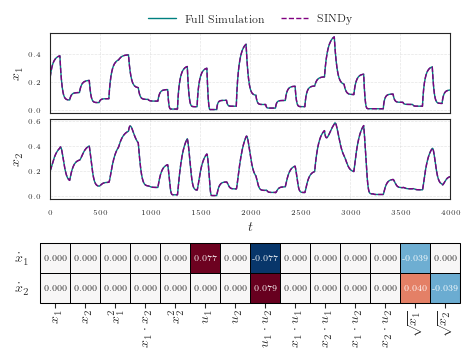

Saved results/TwoTank_Dynamics.pdf


In [8]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import ticker, patches
import seaborn as sns

# ========= Simulation outputs -> aligned time series =========
# pred_traj: shape (nx, T_pred); true_traj: shape (nx, T_true)
pred_traj = test_output['xn'][:, :-1, :].detach().cpu().numpy().reshape(-1, nx).T
true_traj = test_data['X'].detach().cpu().numpy().reshape(-1, nx).T

# Align lengths (pred is typically one step shorter)
T_pred = pred_traj.shape[1]
true_traj = true_traj[:, :T_pred]
time = np.arange(T_pred)

# ========= Coefficient matrix (rows = states, cols = library terms) =========
def rowify_coef(fx):
    c = fx.coef.detach().cpu().numpy()
    if c.ndim == 1:        # (n_terms,)
        return c[None, :]
    if c.shape[0] == 1:    # (1, n_terms)
        return c
    if c.shape[1] == 1:    # (n_terms, 1)
        return c.T
    # assume (n_terms, n_outputs) -> use one column per state model, so transpose
    return c.T

coef_matrix = np.vstack([rowify_coef(fx) for fx in fx_models])

# library names from the first model
function_names_latex = convert_to_latex(fx_models[0].library.function_names)
n_terms = len(function_names_latex)

# ========= Figure layout params =========
FONT_SIZE_COEFS_LABELS = 10
FONT_SIZE_COEFS = 6
CELL_SIZE = 0.3
TS_FIG_WIDTH = 5
TS_FIG_HEIGHT = 2.5

sns.set_style("white")
plt.rcParams.update({"text.usetex": True, "font.family": "serif"})

heatmap_width = n_terms * CELL_SIZE
heatmap_height = 1.5
fig_height = TS_FIG_HEIGHT + heatmap_height
fig = plt.figure(figsize=(TS_FIG_WIDTH, fig_height))

# ========= Time-series plots =========
top_margin = 0.55
gap = 0.015
plot_height = 0.2
plot_width = 0.8
left_margin = (1 - plot_width) / 2

ax0 = fig.add_axes([left_margin, top_margin, plot_width, plot_height])
ax1 = fig.add_axes([left_margin, top_margin - plot_height - gap, plot_width, plot_height])

ax0.plot(time, true_traj[0], color='teal', label='Full Simulation', linewidth=1)
ax0.plot(time, pred_traj[0], color='purple', linestyle='--', linewidth=1, label='SINDy')
ax0.set_ylabel(r"$x_1$")
ax0.set_xlim([0, len(time)])

ax1.plot(time, true_traj[1], color='teal', linewidth=1)
ax1.plot(time, pred_traj[1], color='purple', linestyle='--', linewidth=1, label='SINDy')
ax1.set_ylabel(r"$x_2$")
ax1.set_xlabel(r"$t$")
ax1.set_xlim([0, len(time)])

tick_spacing = 0.2
ax0.yaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))
ax0.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
ax0.tick_params(axis='y', labelsize=5)
ax0.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax1.yaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))
ax1.tick_params(axis='both', labelsize=5)

# ========= Heatmap (centered below) =========
fx_labels = [rf"$\dot{{x}}_{i+1}$" for i in range(coef_matrix.shape[0])]
heatmap_width_figunits = heatmap_width / TS_FIG_WIDTH
heatmap_left = (1 - heatmap_width_figunits) / 2
ax3 = fig.add_axes([heatmap_left, 0.05, heatmap_width_figunits, 0.2])

sns.heatmap(coef_matrix,
            annot=True,
            fmt=".3f",
            cmap="RdBu_r",
            center=0,
            square=True,
            linewidths=0.5,
            linecolor='black',
            xticklabels=function_names_latex,
            yticklabels=fx_labels,
            cbar=False,
            annot_kws={"size": FONT_SIZE_COEFS},
            ax=ax3)

rect = patches.Rectangle((0, 0), coef_matrix.shape[1], coef_matrix.shape[0],
                         linewidth=0.75, edgecolor='black',
                         facecolor='none', clip_on=False, zorder=10)
ax3.add_patch(rect)
ax3.tick_params(axis='x', rotation=90, labelsize=FONT_SIZE_COEFS_LABELS, pad=1)
ax3.tick_params(axis='y', rotation=0, labelsize=FONT_SIZE_COEFS_LABELS, pad=5)
ax3.xaxis.tick_bottom()

# ========= Legend just above ax0 =========
handles, labels = ax0.get_legend_handles_labels()
bbox = ax0.get_position()
legend_bottom = bbox.y1 + 0.01
legend_ax = fig.add_axes([bbox.x0, legend_bottom, bbox.width, 0.05])
legend_ax.axis("off")
legend_ax.legend(handles, labels, loc='center', ncol=len(handles),
                 fontsize=8, frameon=False, handlelength=2.5, columnspacing=1.5)

# ========= Save =========
out = "results/TwoTank_Dynamics.pdf"
fig.savefig(out, format="pdf", bbox_inches="tight")
plt.show()
print(f"Saved {out}")


### Policy Results

#### Load trained policies:

In [9]:
from neuromancer.modules import blocks
from neuromancer.modules.activations import activations

run_id = 3
### SPARSE DICTIONARY (SD) MODELS ###
SD_SINDy_policies = [fx_policy_library(nx=nx, nref=1,
                              policy_name=f"u_{k}",
                              seed=1, device=device)
                              for k in range(nu)]


models_dir = f"results/tests/sparse/run_{run_id}/SINDy/saved_models"
for i, model in enumerate(SD_SINDy_policies):
    pattern = os.path.join(models_dir, f"trained_policy_{i}_*.pth")
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(f"No checkpoint for u{i} in {models_dir}")

    ckpt = max(matches, key=os.path.getmtime)
    state_dict = torch.load(ckpt, weights_only=True)
    model.load_state_dict(state_dict)
    model.to(device).eval()
    print(f"Loaded SD-SINDy policy:  u{i} from {os.path.basename(ckpt)}")



SD_WB_policies = [fx_policy_library(nx=nx, nref=1,
                              policy_name=f"u_{k}",
                              seed=1, device=device)
                              for k in range(nu)]



models_dir = f"results/tests/sparse/run_{run_id}/WB/saved_models"
for i, model in enumerate(SD_WB_policies):
    pattern = os.path.join(models_dir, f"trained_policy_{i}_*.pth")
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(f"No checkpoint for u{i} in {models_dir}")

    ckpt = max(matches, key=os.path.getmtime)
    state_dict = torch.load(ckpt, weights_only=True)
    model.load_state_dict(state_dict)
    model.to(device).eval()
    print(f"Loaded SD-WB policy: u{i} from {os.path.basename(ckpt)}")




### NEURAL NETWORK (NN) MODELS ###
nn_files = "results/tests/neural"
with open(nn_files+"/nn_config.json", "r") as f:
    nn_config = json.load(f)

net_SINDy = blocks.MLP_bounds(insize=nx + nref, outsize=nu, hsizes=nn_config["layers"],
                    nonlin=activations['gelu'], min=umin, max=umax)
nn_SINDy = Node(net_SINDy, ['xn', 'r'], ['u'], name='neural policy')
nn_SINDy.load_state_dict(torch.load(nn_files+"/policy_neural_sindy.pth", weights_only=True))


net_WB = blocks.MLP_bounds(insize=nx + nref, outsize=nu, hsizes=nn_config["layers"],
                    nonlin=activations['gelu'], min=umin, max=umax)
nn_WB = Node(net_WB, ['xn', 'r'], ['u'], name='neural policy')
nn_WB.load_state_dict(torch.load(nn_files+"/policy_neural_WB.pth", weights_only=True))




Loaded SD-SINDy policy:  u0 from trained_policy_0_20250808_150421.pth
Loaded SD-SINDy policy:  u1 from trained_policy_1_20250808_150421.pth
Loaded SD-WB policy: u0 from trained_policy_0_20250808_150421.pth
Loaded SD-WB policy: u1 from trained_policy_1_20250808_150421.pth


<All keys matched successfully>

In [10]:
import torch
import torch.nn as nn

class VectorizedPolicy(nn.Module):
    def __init__(self, coef_u0, coef_u1, umin=None, umax=None):
        """
        coef_u0, coef_u1: lists or tensors of coefficients for each basis term
        umin, umax: scalar limits (optional) for clipping outputs
        """
        super().__init__()
        self.register_buffer("coef_u0", torch.as_tensor(coef_u0, dtype=torch.get_default_dtype()))
        self.register_buffer("coef_u1", torch.as_tensor(coef_u1, dtype=torch.get_default_dtype()))
        self.umin = umin
        self.umax = umax

    def forward(self, x: torch.Tensor, r: torch.Tensor) -> torch.Tensor:
        if x.dim() != 2 or x.size(-1) != 2:
            raise ValueError("x must be of shape (B, 2)")

        x0, x1 = x[:, 0], x[:, 1]
        r0, r1 = r[:, 0], r[:, 1]

        c2x0 = torch.cos(2 * x0)  # reused in u0 and u1
        c2x1 = torch.cos(2 * x1)  # reused in u0 and u1
        c2r0 = torch.cos(2 * r0)
        s2r0 = torch.sin(2 * r0)
        # Basis for u0: cos(2*x0), cos(2*x1), cos(2*r0), sin(2*r0)
        Phi_u0 = torch.stack([
            c2x0,
            c2x1,
            c2r0,
            s2r0
        ], dim=1)

        # Basis for u1: cos(2*x0), cos(2*x1)
        Phi_u1 = torch.stack([
            c2x0,
            c2x1
        ], dim=1)

        u0 = (Phi_u0 @ self.coef_u0)
        u1 = (Phi_u1 @ self.coef_u1)

        # Concatenate into (B, 2)
        U = torch.stack([u0, u1], dim=1)

        return torch.clamp(U, self.umin, self.umax).squeeze(-1)


#### Create a system using trained policies:

In [11]:
pruned_SD_SINDy_policies = [prune_model(fp) for fp in SD_SINDy_policies]
pruned_SD_WB_policies = [prune_model(fp) for fp in SD_WB_policies]

vectorized_SD_SINDy_policies = VectorizedPolicy(pruned_SD_SINDy_policies[0].coef, pruned_SD_SINDy_policies[1].coef,
                                                umin=umin, umax=umax)
vectorized_SD_WB_policies = VectorizedPolicy(pruned_SD_WB_policies[0].coef, pruned_SD_WB_policies[1].coef,
                                                umin=umin, umax=umax)

SD_SINDy_policy_node = Node(
            lambda xn, r: vectorized_SD_SINDy_policies(xn,r),
            ['xn', 'r'], ['u'],
            name="policy_combined"
        )

SD_WB_policy_node = Node(
            lambda xn, r: vectorized_SD_WB_policies(xn,r),
            ['xn', 'r'], ['u'],
            name="policy_combined"
        )


two_tank = ode.TwoTankParam()
two_tank.c1 = nn.Parameter(torch.tensor(gt_model.c1), requires_grad=False)
two_tank.c2 = nn.Parameter(torch.tensor(gt_model.c2), requires_grad=False)

# Euler integrator for ODE system
gt_integrator = integrators.Euler(two_tank, h=torch.tensor(ts))
gt_integrator_node = Node(gt_integrator, ['xn', 'u'], ['xn'], name='model')


SD_SINDy_system = System([SD_SINDy_policy_node, gt_integrator_node])
SD_WB_system = System([SD_WB_policy_node, gt_integrator_node])
NN_SINDy_system = System([nn_SINDy, gt_integrator_node])
NN_WB_system = System([nn_WB, gt_integrator_node])

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import torch.nn.functional as F

import importlib
import results.utils
importlib.reload(results.utils)
from results.utils import mpc_solve_adaptive_horizon, evaluate_controllers_over_seeds


In [14]:

# ---- Setup ----
nsteps = 750
step_length = 150
N=50
seed = 8
rng = np.random.default_rng(seed)
torch.manual_seed(seed)

# Generate reference signal
np_ref_1 = psl.signals.step(nsteps+2, 1, min=0.2, max=0.8, randsteps=nsteps//step_length, rng=rng)
R_1 = torch.tensor(np_ref_1, dtype=torch.float32).reshape(1, nsteps+2, 1)
torch_ref = torch.cat([R_1, R_1], dim=-1)
xn_test = torch.rand(1, 1, nx, dtype=torch.float32)

# Initial data
data = {
    'xn': xn_test.to(device),
    'x1_n': xn_test[:, :, 0:1].to(device),
    'x2_n': xn_test[:, :, 1:2].to(device),
    'r': torch_ref.to(device)
}


# Run controllers
SD_SINDy_system.nsteps = nsteps
SD_WB_system.nsteps = nsteps
NN_SINDy_system.nsteps = nsteps
NN_WB_system.nsteps = nsteps

sparse_sindy_trajectories = SD_SINDy_system(data)
sparse_WB_trajectories = SD_WB_system(data)
NN_wb_trajectories = NN_WB_system(data)
NN_sindy_trajectories = NN_SINDy_system(data)
MPC_trajectories = mpc_solve_adaptive_horizon(data, gt_model, N_max=N, N_min=2, nsim=nsteps, step_length=step_length, Ru=0.0, Rdu=0.01)

# ---- Process data for plotting ----
Y_list = [
    sparse_sindy_trajectories['xn'].detach().cpu().reshape(nsteps + 1, nx),
    #sparse_WB_trajectories['xn'].detach().cpu().reshape(nsteps + 1, nx),
    NN_wb_trajectories['xn'].detach().cpu().reshape(nsteps + 1, nx),
    #NN_sindy_trajectories['xn'].detach().cpu().reshape(nsteps + 1, nx),
    MPC_trajectories['xn'].reshape(nsteps + 1, nx)
]

U_list = [
    sparse_sindy_trajectories['u'].detach().cpu().reshape(nsteps, nu),
    #sparse_WB_trajectories['u'].detach().cpu().reshape(nsteps, nu),
    NN_wb_trajectories['u'].detach().cpu().reshape(nsteps, nu),
    #NN_sindy_trajectories['u'].detach().cpu().reshape(nsteps, nu),
    MPC_trajectories['u'].reshape(nsteps, nu)
]

R = sparse_sindy_trajectories['r'].detach().cpu()[:,:nsteps+1].reshape(nsteps + 1, nref)

# Constraints
Umin = umin * np.ones([nsteps, nu])
Umax = umax * np.ones([nsteps, nu])
Ymin = xmin * np.ones([nsteps + 1, nx])
Ymax = xmax * np.ones([nsteps + 1, nx])

# ---- Compute MSE losses ----
losses = []
for traj in [sparse_sindy_trajectories, sparse_WB_trajectories, NN_wb_trajectories, NN_sindy_trajectories, MPC_trajectories]:
    pred = traj['xn']
    ref = traj['r'][:,:nsteps+1]
    losses.append(F.mse_loss(pred, ref).item())


In [93]:
import results.utils
importlib.reload(results.utils)
from results.utils import *

controller_labels = ["SD-SINDy", "NN-WB", "MPC"]
style_map = {
    "NN-WB": ("-", 1.0, 0.5, "darkorange"),
    "MPC": ("-", 1.0, 0.5, "darkgreen"),
    "SD-SINDy": ("-", 1.0, 0.94, "royalblue"),
}


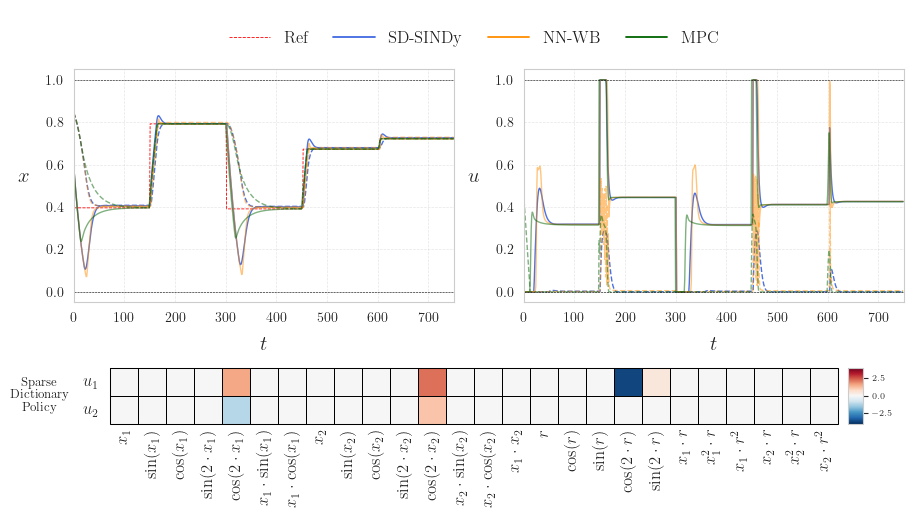

In [94]:
combined_controller_and_two_policy_heatmaps(
    Y_list=Y_list,
    U_list=U_list,
    controller_labels=controller_labels,
    fx_policy_SINDy=SD_SINDy_policies,
    fx_policy_WB=SD_WB_policies,
    fx_policy_labels=[r"${u}_1$", r"${u}_2$"],
    R=R,
    style_map=style_map,
    TS_FIG_WIDTH=10,
    TS_FIG_HEIGHT=10,
    CELL_SIZE=0.28,
    FONT_SIZE_COEFS=12,
    FONT_SIZE_COEFS_LABELS=12,
    xmin=0.0, xmax=1.0,
    umin=0.0, umax=1.0,
    title=None,
    save_name="results/TwoTank_Control_Traj_Coefs.pdf"
)

In [46]:
for fp in pruned_SD_SINDy_policies:
    print(fp)

u_0 = 1.553*cos(2*x_0) + 2.213*cos(2*x_1) + -3.687*cos(2*r_0) + 0.454*sin(2*r_0)

u_1 = -1.136*cos(2*x_0) + 1.146*cos(2*x_1)



#### Evaluate on multiple seeds

In [25]:
import importlib
import results.utils
importlib.reload(results.utils)
from results.utils import mpc_solve_adaptive_horizon, evaluate_controllers_over_seeds

summaries = []

for _ in range(20):
    systems = {
        "SD_SINDy": SD_SINDy_system,
        "SD_WB":    SD_WB_system,
        "NN_SINDy": NN_SINDy_system,
        "NN_WB":    NN_WB_system,
        # # # Add an MPC entry if you want to include it in the same sweep:
        #"MPC": None,  # the value is ignored; name prefix "MPC" triggers mpc_solver
    }

    summary = evaluate_controllers_over_seeds(
        systems_dict=systems,
        nsteps=300,
        step_length=100,
        nx=nx,
        xmin=xmin,
        xmax=xmax,
        n_seeds=100,
        # MPC bits (optional; only used for names starting with "MPC")
        mpc_solver=mpc_solve_adaptive_horizon,
        mpc_model=gt_model,
        mpc_params=dict(
            N_max=N, N_min=2, Ru=0.0, Rdu=0.01)
    )

    summaries.append(summary)



=== Evaluating controller: SD_SINDy ===
  Seed 1/100...
  Seed 20/100...
  Seed 40/100...
  Seed 60/100...
  Seed 80/100...
  Seed 100/100...
  Done with SD_SINDy: MSE=7.3240e-03±5.8088e-03, Violation=4.1576e-08±3.8522e-07, Time=7.4521e-02±2.8607e-02

=== Evaluating controller: SD_WB ===
  Seed 1/100...
  Seed 20/100...
  Seed 40/100...
  Seed 60/100...
  Seed 80/100...
  Seed 100/100...
  Done with SD_WB: MSE=7.3426e-03±5.8165e-03, Violation=3.5137e-08±3.2138e-07, Time=7.1055e-02±1.3372e-02

=== Evaluating controller: NN_SINDy ===
  Seed 1/100...
  Seed 20/100...
  Seed 40/100...
  Seed 60/100...
  Seed 80/100...
  Seed 100/100...
  Done with NN_SINDy: MSE=7.3268e-03±5.7566e-03, Violation=5.8123e-08±4.9988e-07, Time=7.2948e-02±1.2715e-02

=== Evaluating controller: NN_WB ===
  Seed 1/100...
  Seed 20/100...
  Seed 40/100...
  Seed 60/100...
  Seed 80/100...
  Seed 100/100...
  Done with NN_WB: MSE=7.2624e-03±5.7514e-03, Violation=4.9996e-08±4.9745e-07, Time=7.4458e-02±1.7704e-02

===

In [32]:
results = 0

for sum in summaries:
    results += sum

results = results/len(summaries)

In [39]:
results[['tracking_mse_mean', 'tracking_mse_std', 'violation_mse_mean',
         'violation_mse_std', 'time_mean', 'time_std']]

,tracking_mse_mean,tracking_mse_std,violation_mse_mean,violation_mse_std,time_mean,time_std
controller,,,,,,
SD_SINDy,0.007324,0.005809,4.157601e-08,3.852199e-07,0.075962,0.026283
SD_WB,0.007343,0.005817,3.513703e-08,3.213750e-07,0.077243,0.028028
NN_SINDy,0.007327,0.005757,5.812280e-08,4.998850e-07,0.077831,0.024060
NN_WB,0.007262,0.005751,4.999607e-08,4.974546e-07,0.082861,0.032284


In [65]:
import torch
import time

def benchmark_policy(policy, nx=2, nref=1, batch_size=1024, iters=2000, device="cpu"):
    # Random test inputs
    X = torch.rand(batch_size, nx, device=device)
    R = torch.rand(batch_size, nref, device=device)

    policy.eval()
    with torch.no_grad():
        # Warm-up (especially important for GPU timing)
        for _ in range(10):
            _ = policy(X, R)

        if device == "cuda":
            torch.cuda.synchronize()

        start = time.time()
        for _ in range(iters):
            _ = policy(X, R)
        if device == "cuda":
            torch.cuda.synchronize()

    total_time = (time.time() - start)
    avg_time = total_time / iters
    return avg_time*1e6



In [66]:
avgs_SD = []
avgs_NN = []
for _ in range(200):
    avg_SD = benchmark_policy(vectorized_SD_SINDy_policies, nx=2, nref=2, batch_size=1, iters=1000, device="cpu")
    avg_NN = benchmark_policy(net_SINDy, nx=2, nref=2, batch_size=1, iters=1000, device="cpu")
    avgs_SD.append(avg_SD)
    avgs_NN.append(avg_NN)


In [67]:
print(np.mean(avgs_SD))
print(np.mean(avgs_NN))

31.18587827682495
33.66090679168701
